# Домашнее задание 2. Работа с изображениями

В этом задании предлагается решить простейшую задачу рапознавания лиц. Вам нужно будет научить модель для пары картинок определять, разные ли люди на них изображены.

Работать будем с датасетом фотографий известных людей. Скачать его можно [тут](https://disk.360.yandex.ru/d/oAmJgPESjP33hg). В нём представлены 150 человек, для каждого по 6-9 фотографий. Всего около 1000 изображений.

__Задание__. Вам потребуется выполнить два задания:

1) Реализовать модель бинарной классификации и добиться приемлемого качества.

2) Реализовать триплетную функцию потерь и улучшить качество предсказаний с ее помощью.

Напишите краткий отчёт о проделанных экспериментах. Что сработало и что не сработало? Почему вы решили, сделать так, а не иначе? Обязательно указывайте ссылки на чужой код, если вы его используете. Обязательно ссылайтесь на статьи / блогпосты / вопросы на stackoverflow / видосы от ютуберов-машинлернеров / курсы / подсказки от Дяди Васи и прочие дополнительные материалы, если вы их используете.

__Во всех заданиях будем придерживаться следующих правил__:
1. Использовать внешние данные для обучения строго запрещено. Также запрещено обучаться на валидационной выборке.
2. Все задания должны быть выполнены без использования предобученных моделей и готовых реализаций. Тем не менее:
    - В заданиях, где требуется достичь некоторого качества модели, разрешается использовать предобученные модели. Но __оценка за задние будет снижена__ (для каждого задания будет отдельно указано, на сколько).
    - В некоторых заданиях может сильно помочь библотека [pytorch-metric-learning](https://kevinmusgrave.github.io/pytorch-metric-learning/). Вы можете использовать готовые реализации из неё, но __максимальный балл за задание также будет снижен__.

__Советы и указания__:
 - Наверняка вам потребуется много гуглить о том, как заставить это всё работать. Это нормально, все гуглят. Но не забывайте, что нужно быть готовым за скатанный код отвечать :)
 - Рекомендуем использовать шаблоны ниже. Однако делать это мы не заставляем. Если вам так неудобно, то можете писать код в удобном стиле. Однако учтите, что чрезмерное изменение нижеперечисленных шаблонов увеличит количество вопросов к вашему коду :)
 - Валидируйте. Трекайте ошибки как можно раньше, чтобы не тратить время впустую.
 - Чтобы быстро отладить код, пробуйте обучаться на маленькой части датасета (скажем, 5-10 картинок просто чтобы убедиться что код запускается). Когда вы поняли, что смогли всё отдебажить, переходите обучению по всему датасету
 - На каждый запуск делайте ровно одно изменение в модели/аугментации/оптимайзере, чтобы понять, что и как влияет на результат.
 - Фиксируйте random seed.
 - Правильно нормализуйте данные при создании, пример [тык, но тут и в целом гайд от и до](https://www.pluralsight.com/guides/image-classification-with-pytorch)
 - Начинайте с простых моделей и постепенно переходите к сложным. Обучение лёгких моделей экономит много времени. Можно написать свою модель руками, а можно импортировать не предобученную сетку известной архитектуры из модуля `torchvision.models`. Один из способов как можно сделать: [документация (полезная)](https://pytorch.org/vision/stable/models.html)
 - Используйте все возможные методы оптимизации и эксперемнтируйте с ними.
 - Ставьте расписание на learning rate. Уменьшайте его, когда лосс на валидации перестаёт убывать.
 - Model Checkpointing. Сохраняйте свой прогресс (модели), чтобы когда что-то пойдет не так вы сможете начать с этого места или просто воспроизвести свои результаты модели, которые обучали.
    * Пример как можно с wandb тут: [Сохраняем лучшие модели в wandb](https://docs.wandb.ai/guides/integrations/lightning)
    * По простому можно так: [Сохраняем модели в pytorch дока](https://pytorch.org/tutorials/beginner/saving_loading_models.html)
 - Советуем использовать GPU. Если у вас его нет, используйте google colab. Если вам неудобно его использовать на постоянной основе, напишите и отладьте весь код локально на CPU, а затем запустите уже написанный ноутбук в колабе.

Good luck & have fun! :)

In [1]:
import os
import tqdm
import numpy
import torch
import pandas
import random
import torchvision
import sklearn.metrics
import torch.utils.data
import matplotlib.pyplot as plt
import torchvision.transforms.v2

In [2]:
# Можно использовать, но балл за соответствующие задания будет снижен.
import pytorch_metric_learning.distances
import pytorch_metric_learning.samplers
import pytorch_metric_learning.losses

ModuleNotFoundError: No module named 'pytorch_metric_learning'

In [3]:
# Обязательно вызывайте эту функцию перед каждый запуском обучения!
# Если проверяющий не сможет воспроизвести результат, оценка за задание будет снижена.
def set_random_seed(seed: int = 42):
    random.seed(seed)
    numpy.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

### [1.5 балла] Часть 1. Подготовка данных.

##### [0.5 балла] Задание 1.1. Считать датасет.

Сначала нужно считать датасет с фотографиями и посмотреть на его устройство.

In [4]:
# Шаг 1: Загрузка файла data.zip
from google.colab import files

uploaded = files.upload()  # Это откроет диалоговое окно для загрузки файла

# Шаг 2: Распаковка ZIP-файла
import zipfile
import os

# Предполагаем, что файл называется 'data.zip'
zip_file_path = 'data.zip'

# Создаем папку для распаковки
os.makedirs('data', exist_ok=True)

# Распаковываем файл
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall('data')

Saving data.zip to data (3).zip


In [5]:
from torchvision import transforms as T
transform =torchvision.transforms.Compose([
    T.ToTensor(),
    T.Normalize((0.1307,), (0.3081,)),
]) ### YOUR CODE HERE ###

train_ds = torchvision.datasets.ImageFolder("/content/data/data/training", transform = transform)
test_ds = torchvision.datasets.ImageFolder("/content/data/data/testing", transform = transform)

Давайте посмотрим на примеры фотографий. Нарисуйте несколько.

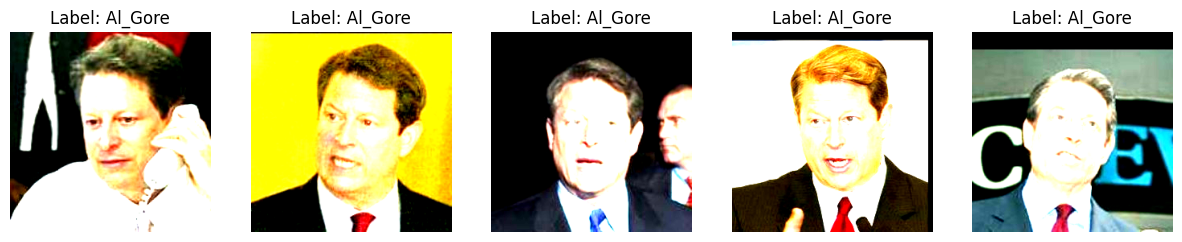

In [6]:
import matplotlib.pyplot as plt

# Функция для отображения изображений
def show_images(dataset, num_images=5):
    plt.figure(figsize=(15, 5))
    for i in range(num_images):
        img, label = dataset[i]
        img = img.permute(1, 2, 0)  # Переставляем оси для правильного отображения
        plt.subplot(1, num_images, i + 1)
        plt.imshow(img)
        plt.title(f'Label: {dataset.classes[label]}')
        plt.axis('off')
    plt.show()

# Покажем несколько изображений из обучающего датасета
show_images(train_ds, num_images=5)

Наконец, следует вывести распределение фотографий по людям и убедиться, что для каждого человека действительно предствалено 6-9 фотографий.

/tmp/ipython-input-724889796.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


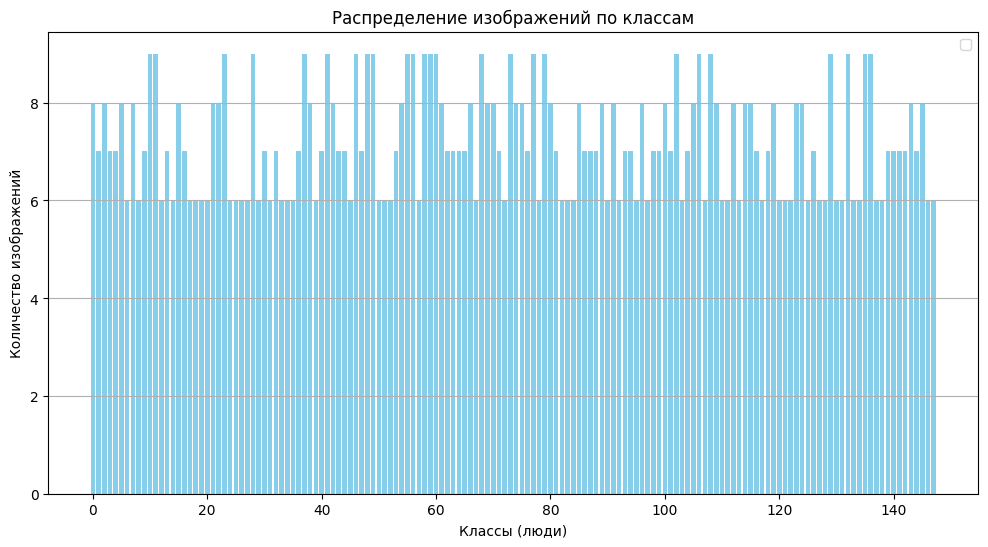

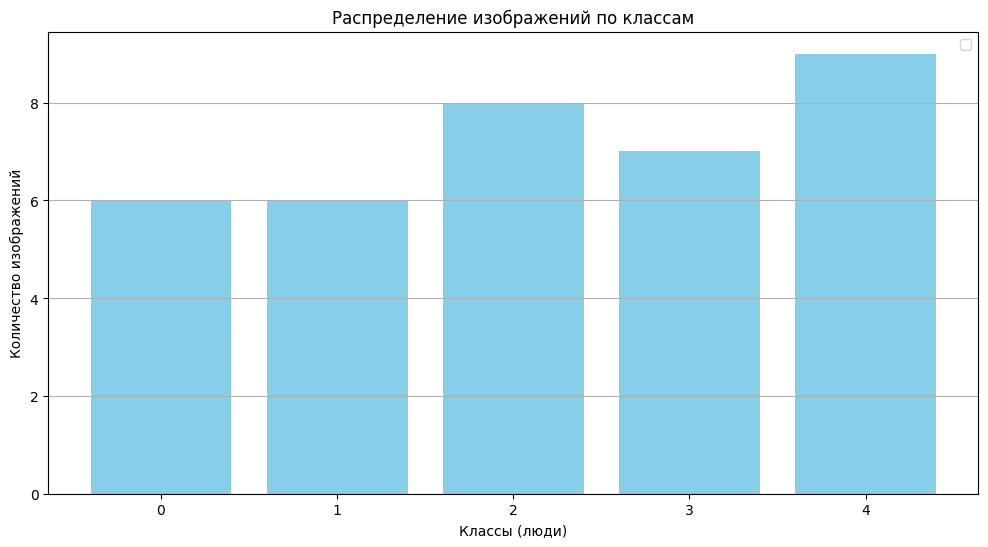

In [7]:
from collections import Counter
def show_class_distribution(targets):
    if isinstance(targets,torch.Tensor):
      targets=targets.cpu().numpy().tolist()
    class_counts = Counter(targets)

    # Извлекаем классы и их количество
    classes = list(class_counts.keys())
    counts = list(class_counts.values())

    # Визуализируем распределение
    plt.figure(figsize=(12, 6))
    plt.bar(classes, counts, color='skyblue')
    plt.xlabel('Классы (люди)')
    plt.ylabel('Количество изображений')
    plt.title('Распределение изображений по классам')
    plt.grid(axis='y')
    plt.legend()
    plt.show()

show_class_distribution(train_ds.targets)
show_class_distribution(test_ds.targets)

##### [0 баллов] Задание 1.2. Датасет пар.

Как было сказано ранее, мы будем обучать модели предсказывать, разные ли люди изображены на фотографиях. Для этого нам надо научиться формировать пары фотографий и целевую переменную из двух классов: 0 и 1. \
Класс 0 означает, что это фотографии одного человека. \
Класс 1 означает фотографии разных людей. \
 \
К счастью, весь датасет уже написан.

In [8]:
class PairDataset(torch.utils.data.Dataset):
    def __init__(self, dataset):
        self.dataset = dataset
        self.targets = [ self._get_target(i) for i in tqdm.trange(len(self)) ]

    def _idx1(self, idx):
        return idx % len(self.dataset)

    def _idx2(self, idx):
        return idx // len(self.dataset)

    def _get_target(self, idx):
        return int(self.dataset.targets[self._idx1(idx)] != self.dataset.targets[self._idx2(idx)])

    def __len__(self):
        return len(self.dataset) ** 2

    def __getitem__(self, idx):
        image1, label1 = self.dataset[self._idx1(idx)]
        image2, label2 = self.dataset[self._idx2(idx)]
        return image1, image2, int(label1 != label2)

train_pairs = PairDataset(train_ds)
test_pairs = PairDataset(test_ds)

100%|██████████| 1296/1296 [00:00<00:00, 976435.78it/s]


/tmp/ipython-input-724889796.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


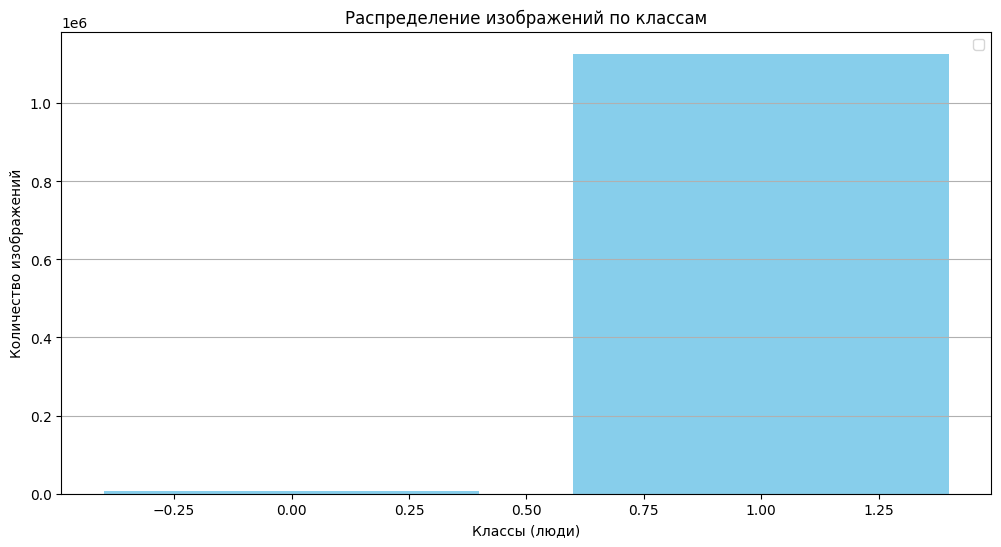

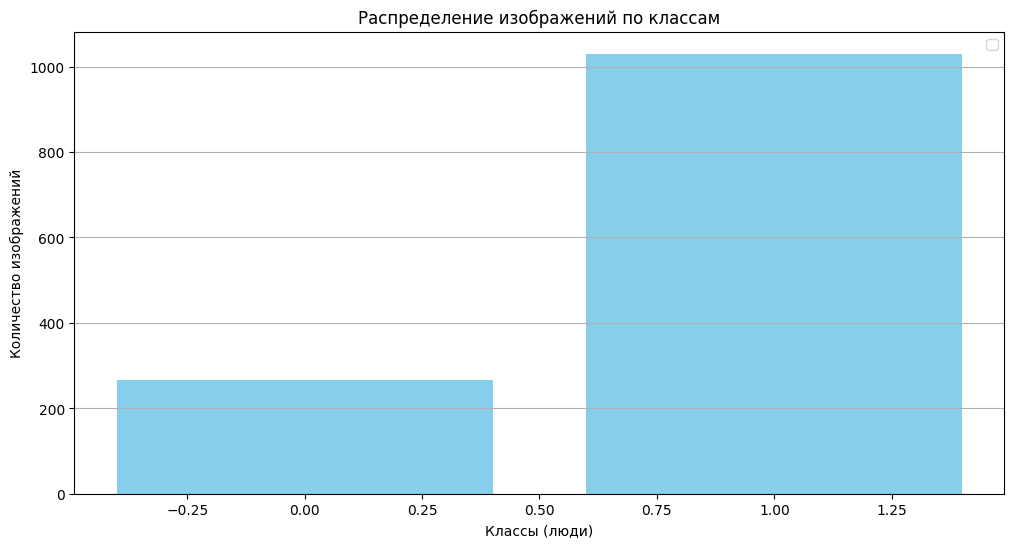

In [10]:
show_class_distribution(train_pairs.targets)
show_class_distribution(test_pairs.targets)

Легко видеть, что пар фотографий разных людей гораздо больше, чем пар фотографий одного человека. Это вполне ожидаемо, но, если не предпринять мер, ведет к двум проблемам:
1. Метрика качества предсказаний должна учитывать дисбаланс классов. В частности, accuracy нам не подойдёт. А использовать будем известный из курса машинного обучения AUC-ROC.
2. Нужно "подтюнить" даталоадер тренировочных данных, чтобы в каждый батч попадало примерно одинаковое количество фотографий каждого класса. Иначе победить деградацию модели к "всегда 1" будет очень сложно.

##### [1 балл] Задание 1.3. Стратифицированный даталоадер.

Для начала решим вторую проблему. Нужно сделать такой даталоадер, чтобы в каждом батче количество элементов класса "0" совпадало с количеством элементов класса "1".

Как известно, стандартный класс `DataLoader` в torch имеет много параметров. В частности, параметр `sampler` позволяет гибко управлять выдачей. Изучите [документацию](https://docs.pytorch.org/docs/stable/data.html#data-loading-order-and-sampler) и реализуйте свой семплер, который решит проблему.

В `pytorch_metric_learning` уже есть готовая реализация того, что нам нужно. Вы можете её найти и использовать. Но в таком случае __максимальный балл за это задание - 0.4__.

/tmp/ipython-input-724889796.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


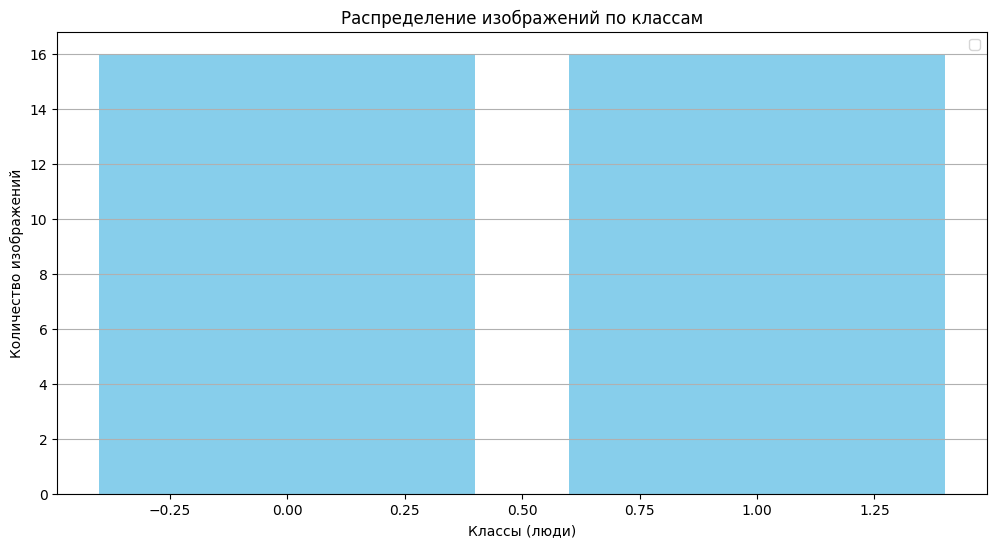

In [15]:
import torch
from torch.utils.data import Sampler
import numpy as np

class BalancedSampler(Sampler):
    def __init__(self, targets, batch_size):
        """
        Sampler для сбалансированной выборки

        Args:
            targets: список/массив меток (0 и 1)
            batch_size: размер батча (должен быть четным)
        """
        self.targets = targets
        self.batch_size = batch_size

        # Разделяем индексы по классам
        self.class_indices = {0: [], 1: []}
        for idx, target in enumerate(targets):
            self.class_indices[target].append(idx)

        # Проверяем, что batch_size четный
        assert batch_size % 2 == 0, "Batch size должен быть четным для сбалансированной выборки"

        # Случайно перемешиваем индексы в каждом классе
        np.random.shuffle(self.class_indices[0])
        np.random.shuffle(self.class_indices[1])

        # Определяем, сколько полных батчей можно создать
        self.num_batches = min(len(self.class_indices[0]), len(self.class_indices[1])) // (batch_size // 2)

    def __iter__(self):
        # Создаем копии списков для безопасного перемешивания
        indices_0 = self.class_indices[0].copy()
        indices_1 = self.class_indices[1].copy()

        # Перемешиваем индексы
        np.random.shuffle(indices_0)
        np.random.shuffle(indices_1)

        # Создаем сбалансированные батчи
        all_indices = []
        for i in range(self.num_batches):
            start_idx = i * (self.batch_size // 2)
            end_idx = start_idx + (self.batch_size // 2)

            # Берем равное количество из каждого класса
            batch_indices = indices_0[start_idx:end_idx] + indices_1[start_idx:end_idx]
            all_indices.extend(batch_indices)

        return iter(all_indices)

    def __len__(self):
        return self.num_batches * self.batch_size

# Создаем и используем семплер
train_pairs_sampler = BalancedSampler(train_pairs.targets, batch_size=32)
train_pairs_loader = torch.utils.data.DataLoader(train_pairs, batch_size=32, sampler=train_pairs_sampler)
test_pairs_loader = torch.utils.data.DataLoader(test_pairs, batch_size=64, shuffle=False)

# Убедимся, что теперь выдача равномерная.
show_class_distribution(next(iter(train_pairs_loader))[2])

In [12]:
train_pairs_sampler = CustomBalancedSampler(train_pairs.targets, batch_size=32)


In [13]:
train_pairs_loader = torch.utils.data.DataLoader(train_pairs, batch_size = 32, sampler = train_pairs_sampler)
test_pairs_loader = torch.utils.data.DataLoader(test_pairs, batch_size = 64, shuffle = False)


In [14]:
# Убедимся, что теперь выдача равномерная.
show_class_distribution(next(iter(train_pairs_loader))[2])

TypeError: unsupported operand type(s) for %: 'list' and 'int'

### [3.5 балла] Часть 2. Классификация.

Начнём с простого: попробуем решить проблему как обычную задачу бинарной классификации. Реализуйте и обучите обычную свёрточную сеть, которая принимает два набора фотографий и предсказывает вероятность, что это фотографии разных людей.

##### [1 балл] Задание 2.1. Модель классификации.

Сначала нужно реализовать модель. В `forward` необходимо принять два батча фотографий. `i`-e число в выводе `forward` должно быть предсказанием для пары из `i`-й фотографии `image1` и `i`-й фотографии `image2`. Подумайте, как это сделать. Возможно, стоит как-нибудь склеить `image1` и `image2`? Или склеить эмбеддинги? А может быть нужен какой-то трешхолд?

Вы вольны использовать любую архитектуру сети. Ассерт в конце ячейки поможет вам убедиться, что модель теоретически делает то, что нужно.

In [16]:
class ClassificationNet(torch.nn.Module):
    def __init__(self):
        super(ClassificationNet, self).__init__()

        # Используем предобученную сеть в качестве энкодера
        self.encoder = torchvision.models.resnet18(pretrained=True)
        # Убираем последний полносвязный слой
        self.encoder.fc = torch.nn.Identity()

        # Замораживаем часть слоев для ускорения обучения
        for param in list(self.encoder.parameters())[:-4]:
            param.requires_grad = False

        # Классификатор для пары эмбеддингов
        self.classifier = torch.nn.Sequential(
            torch.nn.Linear(512 * 2, 256),  # 512 features * 2 images
            torch.nn.ReLU(),
            torch.nn.Dropout(0.3),
            torch.nn.Linear(256, 64),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.2),
            torch.nn.Linear(64, 1),
            torch.nn.Sigmoid()  # Выход в диапазоне [0, 1]
        )

    def forward(self, image1, image2):
        # Получаем эмбеддинги для обоих изображений
        embedding1 = self.encoder(image1)
        embedding2 = self.encoder(image2)

        # Объединяем эмбеддинги
        combined = torch.cat([embedding1, embedding2], dim=1)

        # Классифицируем пару
        output = self.classifier(combined)

        return output.squeeze()  # Убираем размерность 1
model = ClassificationNet()
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

# Тестируем модель
batch = next(iter(train_pairs_loader))
image1, image2, targets = batch[:3]

with torch.no_grad():
    output = model(image1, image2)
    print(f"Input shapes: image1 {image1.shape}, image2 {image2.shape}")
    print(f"Output shape: {output.shape}")
    print(f"Output range: [{output.min():.3f}, {output.max():.3f}]")

# Проверяем ассерт
assert model(*next(iter(train_pairs_loader))[:2]).shape == (32,)
print("✓ Ассерт пройден! Модель работает корректно.")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 94.6MB/s]


Model parameters: 11,455,425
Input shapes: image1 torch.Size([32, 3, 250, 250]), image2 torch.Size([32, 3, 250, 250])
Output shape: torch.Size([32])
Output range: [0.424, 0.524]
✓ Ассерт пройден! Модель работает корректно.


In [ ]:
class ClassificationNet(torch.nn.Module):
    def __init__(self):
        ### YOUR CODE HERE ###
        pass

    def forward(self, image1, image2):
        ### YOUR CODE HERE ###
        pass

# Вы можете использовать этот ассерт в качестве теста, что ваша модель делает то, что нужно.
assert ClassificationNet()(*next(iter(train_pairs_loader))[:2]).shape == (32,)

##### [2 балла] Задание 2.2. Обучение.

Теперь обучите свою модель и добейтесь приемлемого качества. Балл за это задание вычисляется по формуле:

$$ clamp(0, 2.5 \cdot \dfrac{AucRoc - 0.6}{0.2}, 2.5) $$

То есть, для получения полного балла за это задание необходимо добиться AUC-ROC `0.8`

__При использовани предобученных моделей, балл за это задание умножается на 0.5__ (то есть, не более 1)

In [17]:
model = ClassificationNet()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
print(f"Using device: {device}")


Using device: cpu


In [22]:

import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision

def train_model(model, train_loader, test_loader, epochs=6, lr=0.001):
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

    train_losses = []
    test_aucs = []

    best_auc = 0
    best_model_state = None

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}')

        for batch in progress_bar:
            image1, image2, targets = batch[:3]
            image1, image2, targets = image1.to(device), image2.to(device), targets.to(device).float()

            optimizer.zero_grad()

            outputs = model(image1, image2)
            loss = criterion(outputs, targets)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            progress_bar.set_postfix({'Loss': f'{loss.item():.4f}'})

In [23]:
train_model(model,train_pairs_loader,test_pairs_loader)

TypeError: 'module' object is not callable. Did you mean: 'tqdm.tqdm(...)'?

In [ ]:
def calculate_auc(model, dataloader, device):
    return get_auc_roc(model)

# Обучение модели
def train_model(model, train_loader, test_loader, epochs=20, lr=0.001):
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

    train_losses = []
    test_aucs = []

    best_auc = 0
    best_model_state = None

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        progress_bar = tqdm.tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}')

        for batch in progress_bar:
            image1, image2, targets = batch[:3]
            image1, image2, targets = image1.to(device), image2.to(device), targets.to(device).float()

            optimizer.zero_grad()

            outputs = model(image1, image2)
            loss = criterion(outputs, targets)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            progress_bar.set_postfix({'Loss': f'{loss.item():.4f}'})

        # Вычисляем AUC-ROC на тестовой выборке
        test_auc = get_auc_roc(model)

        train_losses.append(running_loss / len(train_loader))
        test_aucs.append(test_auc)

        print(f'Epoch {epoch+1}: Loss = {running_loss/len(train_loader):.4f}, Test AUC = {test_auc:.4f}')

        # Сохраняем лучшую модель

In [ ]:
def get_score(auc_roc):
    return max(0, min(2.5 * (auc_roc - 0.6) / 0.2, 2.5))

def get_auc_roc(your_model):
    preds = []
    targets = []
    your_model.eval()
    for images1, images2, labels in tqdm.tqdm(test_pairs_loader):
        with torch.no_grad():
            output = your_model(images1.to(device), images2.to(device))
        preds.extend(output.detach().cpu().tolist())
        targets.extend(labels.detach().cpu().tolist())
    preds = numpy.array(preds)
    targets = numpy.array(targets)
    return sklearn.metrics.roc_auc_score(targets, preds)

get_score(get_auc_roc(model))

##### [0.5 балла] Задание 2.3. Анализ и отчет.

Опишите свои эксперименты. Проанализируйте результаты. Почему результаты получились не очень хорошими? Может быть, решать задачу через бинарную классификацию - не лучшая идея? Приведите не менее 3 аргументов, почему это так.

### [5 баллов] Часть 3. Распознавание лиц.

Теперь попробуем использовать более хитрые методы, которые лучше подходят для решаемой задачи. В частности, триплетную функцию потерь. Далее наша модель будет не предсказывать вероятность для двух картинок, а формировать эмбеддинги для одной картинки таким образом, чтобы эмбеддинги фотографий одного человека были близки, а разных людей - далеки.

##### [2 балла] Задание 3.1. Триплетная функция потерь.

Напомним теорию. Пусть $A$ - произвольное изображение; $P$ - изображение того же человека (позитивный пример); $N$ - изображение любого другого человека (негативный пример); $f$ - наша нейронная сеть; $\alpha$ - гиперпараметр, отвечающий за желаемый “отступ” – расстояние между латентными представлениями изображений разных людей. Тогда функционал ошибки определяется следующим образом:

$$ L(A, P, N) = max(||f(A) - f(P)|| - ||f(A) - f(N)|| + \alpha, 0) $$

В этом задании вам необходимо реализовать этот функционал. Для удобства в дальнейшем, предлагается сразу реализовать batch-версию. Таким образом, на входе должно быть 2 параметра:
- Набор эмбеддингов размера (batch_size, embedding_size)
- Набор классов (номера людей, чьи это фотографии) размера (batch_size)

Ваша функция должна найти все тройки $(A, P, N)$ и вычислить лосс для них.

В `pytorch_metric_learning` уже есть готовая реализация. Вы можете её найти и использовать. Но в таком случае __максимальный балл за это задание - 0.5__.

In [ ]:
criterion = ### YOUR CODE HERE ###(margin = 0.25)

In [ ]:
# Вы можете использовать этот ассерт в качестве теста
embeddings = torch.tensor([
    [ 1., 2, 3 ],
    [ 1, 3, 4 ],
    [ 4, 5, 6 ]
])
labels = torch.tensor([ 1., 2, 1 ])
assert (criterion(embeddings, labels) - 2.6775) < 1e-4

##### [3 балла] Задание 3.2. Обучение.

Теперь обучите модель и добейтесь приемлемого качества. Балл за это задание вычисляется по формуле:

$$ clamp(0, 3 \cdot \dfrac{AucRoc - 0.8}{0.15}, 3) $$

То есть, для получения полного балла за это задание необходимо добиться AUC-ROC `0.95`

При необходимости, вы можете улучшить функцию потерь. Например, учитывать не все тройки, а только "сложные", как это умеет делать реализация в `pytorch_metric_learning`. Также подумайте над даталоадером. Возможно, имеет смысл брать в батч одинаковое количество фотографий каждого человека по аналгии с заданием 1.3? Тем не менее имейте в виду, что для получения полного балла за задание, вы должны реализовать все модификации самостоятельно, а не использовать готовые.

__При использовани предобученных моделей, балл за это задание умножается на 0.5__ (то есть, не более 1.5) \
__При использовани pytorch_metric_learning, балл за это задание уменьшается на 0.5 за каждое использование__

In [ ]:
### YOUR CODE HERE ###

In [ ]:
def get_score(auc_roc):
    return max(0, min(3 * (auc_roc - 0.8) / 0.15, 3))

def get_auc_roc(your_model):
    preds = []
    targets = []
    your_model.eval()
    for images1, images2, labels in tqdm.tqdm(test_pairs_loader):
        with torch.no_grad():
            emb1 = your_model(images1.to(device))
            emb2 = your_model(images2.to(device))
            # Вы можете изменить функцию расстояния между эмбеддингами, если считаете нужным
            dist = ((emb1 - emb2) ** 2).sum(dim = 1)
        preds.extend(dist.detach().cpu().tolist())
        targets.extend(labels.detach().cpu().tolist())
    preds = numpy.array(preds)
    targets = numpy.array(targets)
    return sklearn.metrics.roc_auc_score(targets, preds)

get_score(get_auc_roc(model))

##### [0.1 балла] Бонус: распознай себя

В качестве бонуса, загрузите свою фотографию (можно не одну), пропустите ее через модель и определите, на кого из известных людей, по мнению модели, вы больше всего похоже.

In [ ]:
### YOUR CODE HERE ###